<a href="https://colab.research.google.com/github/kazi-amir/ml-learning/blob/main/pytorch-5-projects/4-audio-classification-quran-recitation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4. Audio Classification - Quran Recitation

## Dataset Download

In [1]:
!pip install opendatasets --quiet

In [2]:
!pip install legacy-cgi

In [3]:
import opendatasets as od

In [4]:
od.download("https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kaziamirhamza
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification


100%|██████████| 2.12G/2.12G [00:22<00:00, 99.2MB/s]


## Imports

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import librosa
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from skimage.transform import resize
import time

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
data_df = pd.read_csv("/content/quran-recitations-for-audio-classification/files_paths.csv")
data_df.head()

,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan
4,./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav,Mohammed_Aluhaidan


In [8]:
data_df['FilePath'] = "/content/quran-recitations-for-audio-classification/Dataset" + data_df['FilePath'].str[1:]
data_df.head()

,FilePath,Class
0,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
1,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
2,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
3,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
4,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan


In [9]:
x = data_df['FilePath'][:1]
for c in x:
  print(c)

/content/quran-recitations-for-audio-classification/Dataset/Dataset/Mohammed_Aluhaidan/lohaidan_171.wav


In [10]:
data_df['Class'].nunique(), data_df['Class'].value_counts()

(12,
 Class
 Saud_Alshuraim          696
 Saad_Alghamdi           688
 AbdulRahman_Alsudais    648
 Yasser_Aldossary        576
 Ali_Alhothaify          576
 Bander_Balilah          576
 Maher_Almuaiqly         576
 Abdullah_Albuaijan      504
 Mohammed_Ayoub          480
 Nasser_Alqutami         456
 AbdulBari_Althubaity    456
 Mohammed_Aluhaidan      455
 Name: count, dtype: int64)

In [11]:
data_df.shape

(6687, 2)

## To encode the output classes

In [12]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df['Class'])

LabelEncoder()

In [13]:
train_df = data_df.sample(frac=0.7, random_state=42)
val_test_df = data_df.drop(train_df.index)

val_df = val_test_df.sample(frac=0.5, random_state=42)
test_df = val_test_df.drop(val_df.index)

In [14]:
train_df['Class'] = label_encoder.transform(train_df['Class'])
val_df['Class'] = label_encoder.transform(val_df['Class'])
test_df['Class'] = label_encoder.transform(test_df['Class'])

In [15]:
train_df.shape, val_df.shape, test_df.shape

((4681, 2), (1003, 2), (1003, 2))

## Data Processing and Dataset Creation

In [16]:
class CustomAudioDataset(Dataset):
  def __init__(self, dataframe):
    self.dataframe = dataframe
    self.labels = torch.Tensor(list(dataframe['Class'])).type(torch.LongTensor).to(device)
    self.audios = [torch.Tensor(self.get_spectogram(path)).type(torch.FloatTensor) for path in dataframe['FilePath']]

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    image_path = self.dataframe.iloc[idx, 0]
    label = torch.Tensor(self.labels[idx]).to(device)
    audio = self.audios[idx].unsqueeze(0).to(device)
    return audio, label

  def get_spectogram(self, file_path):
    sr = 22050
    duration = 5

    image_height = 128
    image_weigt = 256

    signal, sr = librosa.load(file_path, sr = sr, duration = duration)
    spec = librosa.feature.melspectrogram(y = signal, sr = sr, n_fft = 2248, hop_length = 512, n_mels=128)
    spec_db = librosa.power_to_db(spec, ref = np.max)
    spec_resized = librosa.util.fix_length(spec_db, size = (duration * sr) // 512+1)
    spec_resized = resize(spec_resized, (image_height, image_weigt), anti_aliasing=True)

    return spec_resized

In [17]:
train_dataset = CustomAudioDataset(dataframe=train_df)
val_dataset = CustomAudioDataset(dataframe=val_df)
test_dataset = CustomAudioDataset(dataframe=test_df)

In [18]:
LR = 0.0001
BATCH_SIZE = 16

In [19]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

## Neural Network Model

In [26]:
class AudioClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
      nn.Conv2d(1, 16, kernel_size=3, padding=1),
      nn.MaxPool2d(2, 2),
      nn.Conv2d(16, 32, kernel_size=3, padding=1),
      nn.MaxPool2d(2, 2),
      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      nn.MaxPool2d(2, 2),
      nn.ReLU(),

      nn.Flatten(),
      nn.Linear((64 * 16 * 32), 4096),
      nn.Dropout(0.5),
      nn.Linear(4096, 1024),
      nn.Dropout(0.5),
      nn.Linear(1024, 512),
      nn.Dropout(0.5),

      nn.Linear(512, len(data_df['Class'].unique()))
    )
  def forward(self, x):
    return self.layers(x)

In [31]:
model_0 = AudioClassifier().to(device)
model_0

AudioClassifier(
  (layers): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): ReLU()
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=32768, out_features=4096, bias=True)
    (9): Dropout(p=0.5, inplace=False)
    (10): Linear(in_features=4096, out_features=1024, bias=True)
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=1024, out_features=512, bias=True)
    (13): Dropout(p=0.5, inplace=False)
    (14): Linear(in_features=512, out_features=12, bias=True)
  )
)

In [32]:
from torchsummary import summary
summary(model_0, input_size=(1, 128, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
         MaxPool2d-2          [-1, 16, 64, 128]               0
            Conv2d-3          [-1, 32, 64, 128]           4,640
         MaxPool2d-4           [-1, 32, 32, 64]               0
            Conv2d-5           [-1, 64, 32, 64]          18,496
         MaxPool2d-6           [-1, 64, 16, 32]               0
              ReLU-7           [-1, 64, 16, 32]               0
           Flatten-8                [-1, 32768]               0
            Linear-9                 [-1, 4096]     134,221,824
          Dropout-10                 [-1, 4096]               0
           Linear-11                 [-1, 1024]       4,195,328
          Dropout-12                 [-1, 1024]               0
           Linear-13                  [-1, 512]         524,800
          Dropout-14                  [

In [33]:
# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model_0.parameters(), lr=LR)

## Model Training Loop

In [35]:
# Training Loop
train_loss_per_epoch = []
train_acc_per_epoch = []
val_loss_per_epoch = []
val_acc_per_epoch = []

EPOCHS = 25

for epoch in range(EPOCHS):
  start_time = time.time()
  total_train_loss = 0
  total_train_acc = 0
  total_val_loss = 0
  total_val_acc = 0

  # Model in Training Mode
  model_0.train()

  for x, y in train_dataloader:
      # Forward Pass
      predictions = model_0(x)

      # Calculate the loss and Acc
      batch_loss = criterion(predictions, y)
      total_train_loss += batch_loss.item()
      batch_acc = (predictions.argmax(dim=1) == y).type(torch.float).sum().item()
      total_train_acc += batch_acc

      # Optimizer Zero Grad
      optimizer.zero_grad()

      # Backward Pass
      batch_loss.backward()

      # Optimizer Step
      optimizer.step()

  with torch.inference_mode():
    # Model in Evaluation Mode
    model_0.eval()

    for x, y in val_dataloader:
      # Forward Pass
      predictions = model_0(x)

      # Calculate the loss and Acc
      batch_loss = criterion(predictions, y)
      total_val_loss += batch_loss.item()
      batch_acc = (predictions.argmax(dim=1) == y).type(torch.float).sum().item()
      total_val_acc += batch_acc

  total_train_loss = total_train_loss / len(train_dataloader)
  total_train_acc = total_train_acc / len(train_dataset)
  total_val_loss = total_val_loss / len(val_dataloader)
  total_val_acc = total_val_acc / len(val_dataset)

  train_loss_per_epoch.append(total_train_loss)
  train_acc_per_epoch.append(total_train_acc * 100)
  val_loss_per_epoch.append(total_val_loss)
  val_acc_per_epoch.append(total_val_acc * 100)

  if epoch % 5 == 0:
    print(f"Epoch: {epoch} | Train Loss: {total_train_loss} | Train Acc: {total_train_acc * 100} | Val Loss: {total_val_loss} | Val Acc: {total_val_acc * 100}")
print(f"Total Time Taken: {time.time() - start_time}")

Epoch: 0 | Train Loss: 2.1622221914371127 | Train Acc: 47.12668233283486 | Val Loss: 0.4415726638029492 | Val Acc: 88.83349950149551
Epoch: 5 | Train Loss: 0.11778756088321733 | Train Acc: 96.38966032898954 | Val Loss: 0.1944783504475795 | Val Acc: 95.81256231306082
Epoch: 10 | Train Loss: 0.08340796115279968 | Train Acc: 97.8637043366802 | Val Loss: 0.25323251234339483 | Val Acc: 95.31405782652044
Epoch: 15 | Train Loss: 0.038767245078310135 | Train Acc: 98.78231147190772 | Val Loss: 0.17434060662413858 | Val Acc: 95.31405782652044
Epoch: 20 | Train Loss: 0.06384307900876193 | Train Acc: 98.84640034180731 | Val Loss: 0.3012491705500398 | Val Acc: 94.81555333998006
Total Time Taken: 17.9178307056427


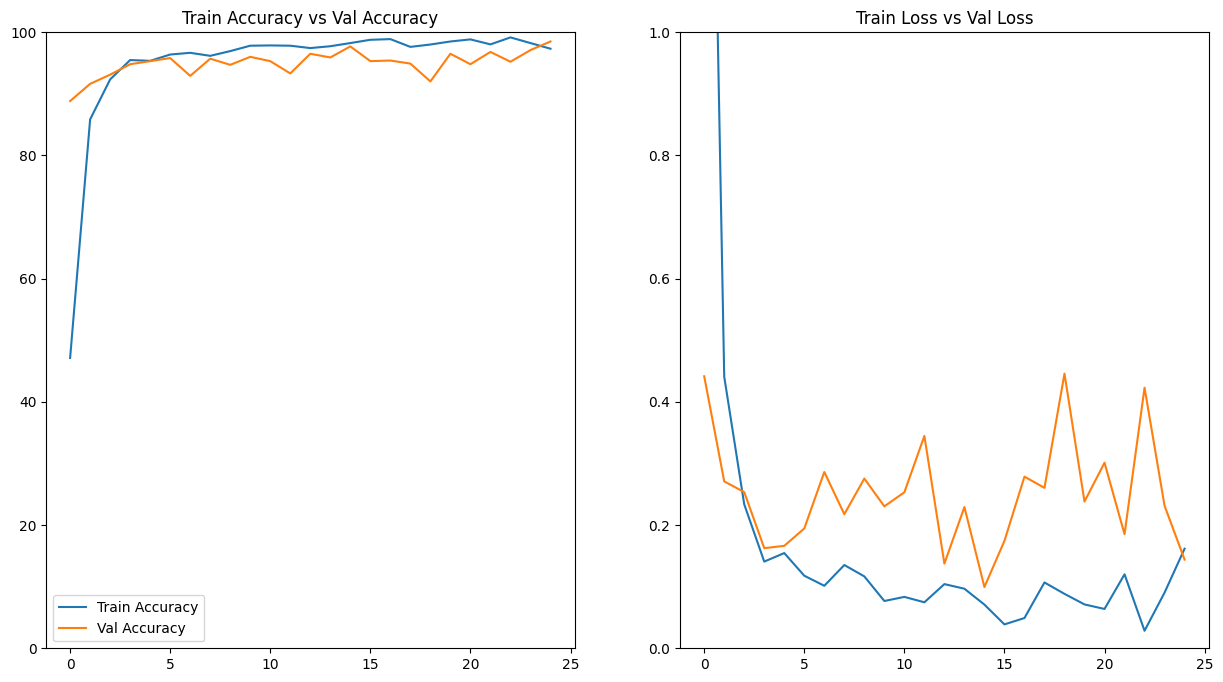

In [38]:
# Plot Train Accuracy vs Val Accuracy and Train Loss vs Val Loss
fig, axs = plt.subplots(1, 2, figsize=(15,8))
axs[0].plot(train_acc_per_epoch, label="Train Accuracy")
axs[0].plot(val_acc_per_epoch, label="Val Accuracy")
axs[0].set_title("Train Accuracy vs Val Accuracy")
axs[0].set_ylim(0, 100)
axs[0].legend()

axs[1].plot(train_loss_per_epoch, label="Train Loss")
axs[1].plot(val_loss_per_epoch, label="Val Loss")
axs[1].set_title("Train Loss vs Val Loss")
axs[1].set_ylim(0, 1)
axs[1].legend

plt.show()

## Testing Model

In [36]:
with torch.inference_mode():
    # Model in Evaluation Mode
    model_0.eval()

    total_test_loss = 0
    total_test_acc = 0

    for x, y in test_dataloader:
      # Forward Pass
      predictions = model_0(x)

      # Calculate the loss and Acc
      batch_loss = criterion(predictions, y)
      total_test_loss += batch_loss.item()
      batch_acc = (predictions.argmax(dim=1) == y).type(torch.float).sum().item()
      total_test_acc += batch_acc

total_test_loss = total_test_loss / len(test_dataloader)
total_test_acc = total_test_acc / len(test_dataset)
print(f"Test Loss: {total_test_loss} | Test Acc: {total_test_acc  * 100}")

Test Loss: 0.28047259448012624 | Test Acc: 96.31106679960119
